In [1]:
import torchmetrics
import torchvision
import torchvision.transforms.v2 as T
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from sklearn.datasets import load_sample_images

sample_images = load_sample_images()['images']
sample_images = np.stack(sample_images)
sample_images = torch.FloatTensor(sample_images)
sample_images /= 255

In [3]:
sample_images_permuted = sample_images.permute(0, 3, 1, 2)

print(sample_images_permuted.dtype, sample_images_permuted.shape)

torch.float32 torch.Size([2, 3, 427, 640])


In [4]:
def plot_image(img_tensor):
    plt.imshow(img_tensor.permute(1, 2, 0))
    plt.axis('off')

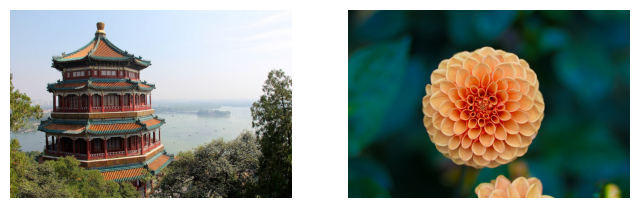

In [5]:
plt.figure(figsize=(8, 4))
for index, img_tensor in enumerate(sample_images_permuted):
    plt.subplot(1, 2, index + 1)
    plot_image(img_tensor)

In [6]:
cropped_images = T.CenterCrop((70, 120))(sample_images_permuted)
cropped_images.shape

torch.Size([2, 3, 70, 120])

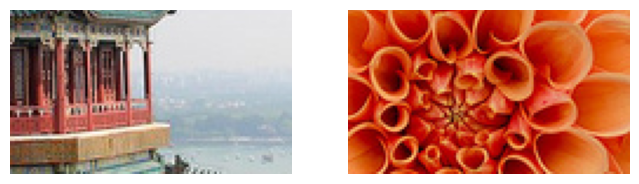

In [7]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plot_image(cropped_images[0])

plt.subplot(1, 2, 2)
plot_image(cropped_images[1])

In [10]:
conv_layer = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=7
)
conv_layer.weight.shape

torch.Size([10, 3, 7, 7])

In [11]:
output = conv_layer(cropped_images)
output.shape

torch.Size([2, 10, 64, 114])

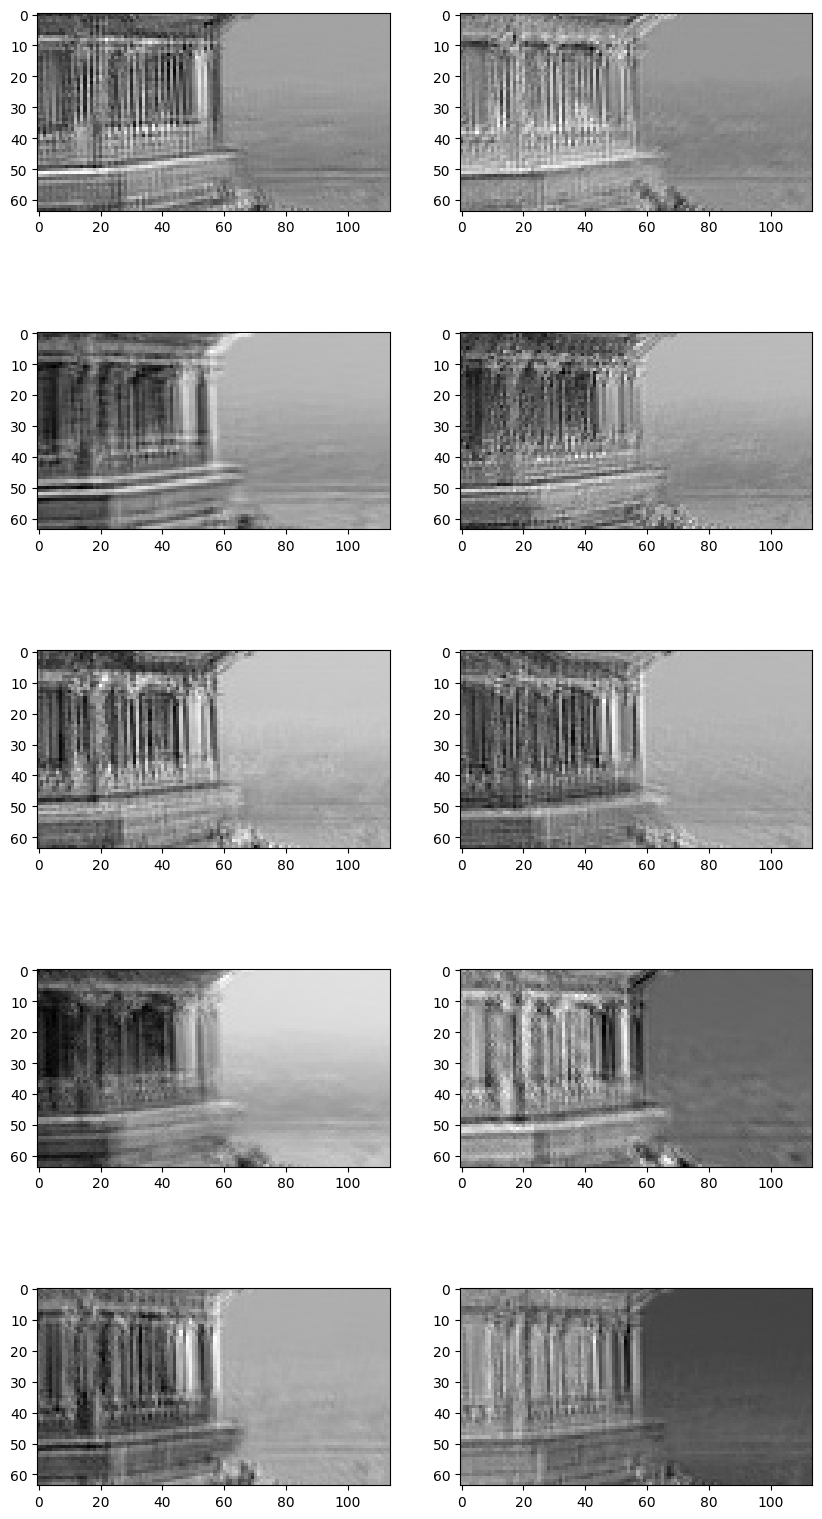

In [18]:
fig, axs = plt.subplots(5, 2, figsize=(10, 20))

with torch.no_grad():
    output = conv_layer(cropped_images)

for ind, ax in enumerate(axs.flat):
    ax.imshow(output[0][ind], cmap='gray') 

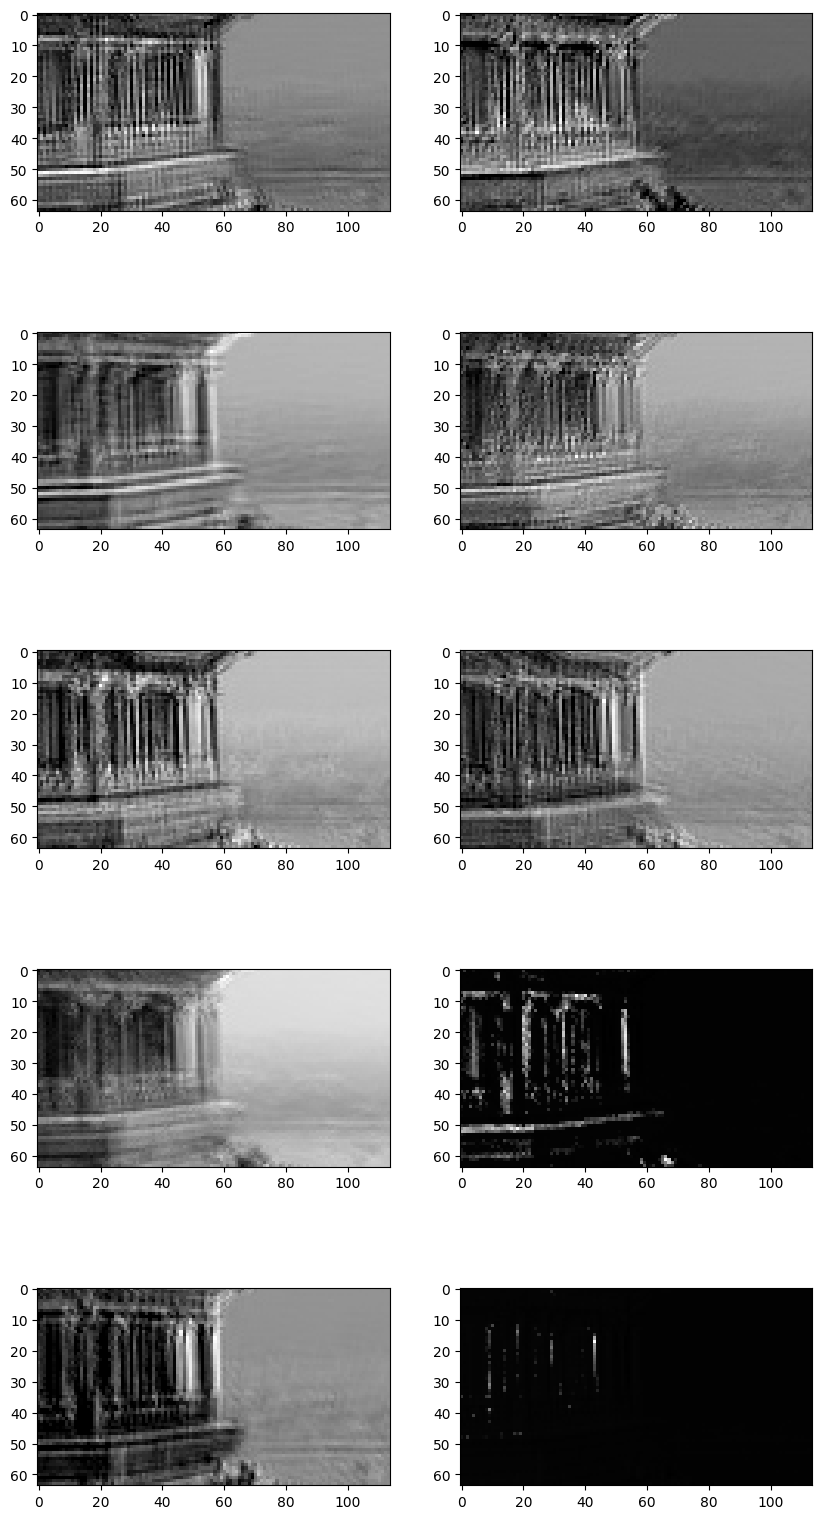

In [19]:
relu_layer = nn.LeakyReLU()
relu_output = relu_layer(output)

fig, axs = plt.subplots(5, 2, figsize=(10, 20))

for ind, ax in enumerate(axs.flat):
    ax.imshow(relu_output[0][ind].detach(), cmap='gray')

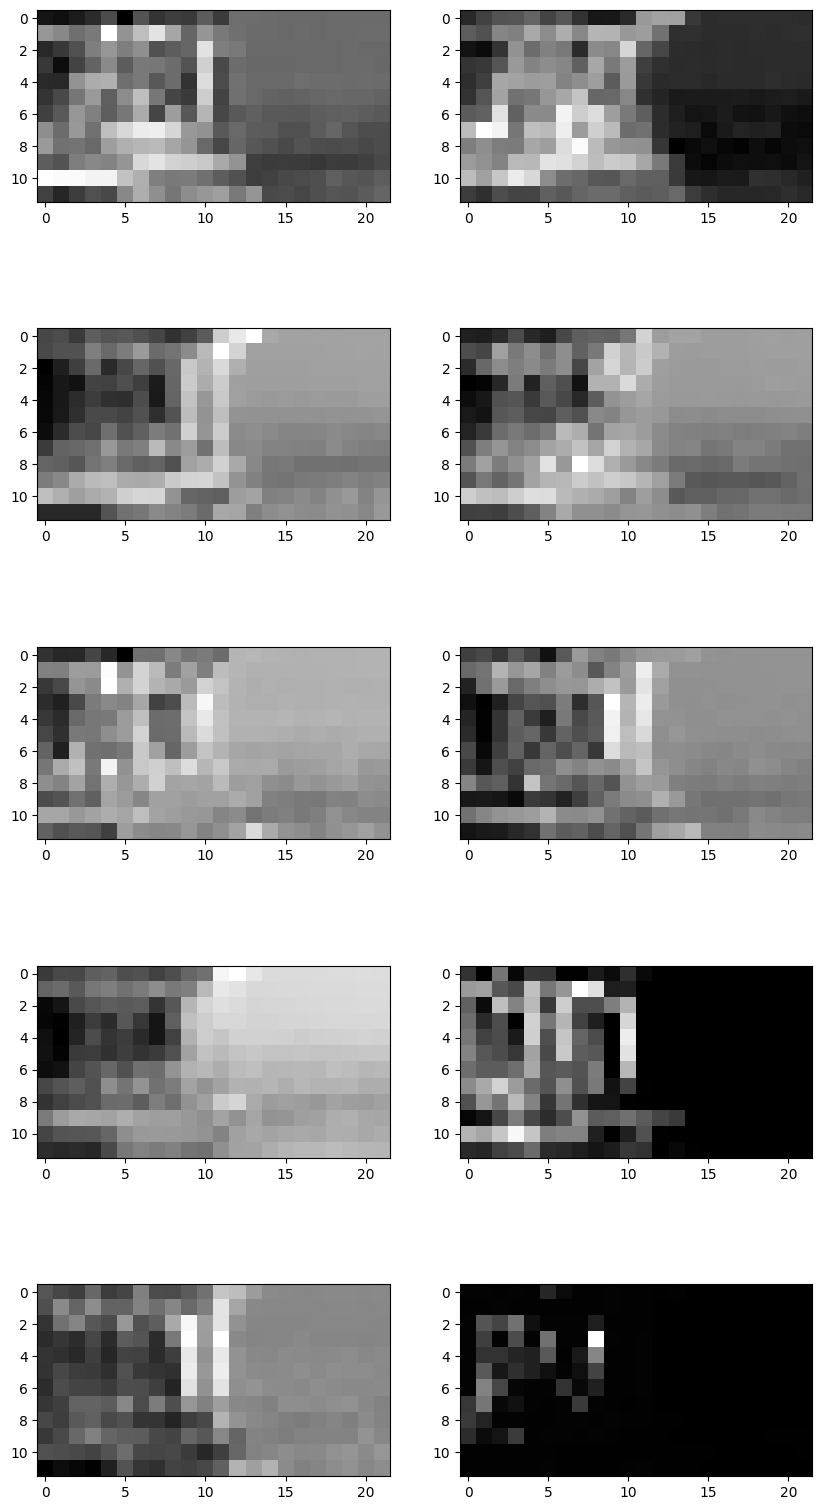

In [20]:
pooling_layer = nn.MaxPool2d(kernel_size=5)
pooling_ouput = pooling_layer(relu_output)

fig, axs = plt.subplots(5, 2, figsize=(10, 20))

for ind, ax in enumerate(axs.flat):
    ax.imshow(pooling_ouput[0][ind].detach(), cmap='gray')